WEEK 2: EXPLORATORY DATA ANALYSIS

✅ Data loaded successfully!
📊 Shape: (117430, 39)
📊 Columns: 39

✅ Verifying Week 1 features:
   ✓ total_stay
   ✓ lead_time_bucket
   ✓ total_guests
   ✓ has_weekend
   ✓ is_summer
   ✓ adr_per_person
   ✓ arrival_month

1. CANCELLATION RATE ANALYSIS
📊 Overall Cancellation Rate: 37.48%

📊 Cancellation Rate by Hotel Type:
hotel
City Hotel      42.207061
Resort Hotel    28.080798
Name: is_canceled, dtype: float64


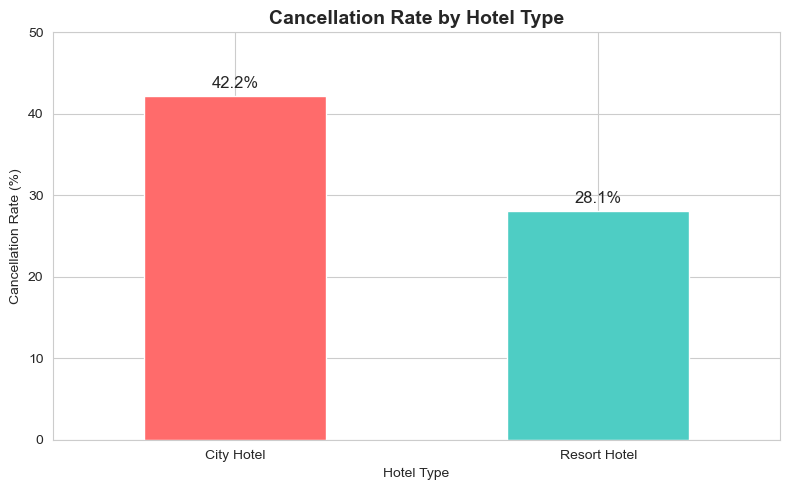


2. LEAD TIME ANALYSIS
lead_time_bucket
Last Minute (0-7)     9.689381
Long (91-180)        44.855764
Medium (31-90)       37.919268
Short (8-30)         28.137901
Very Long (180+)     57.202786
Name: is_canceled, dtype: float64


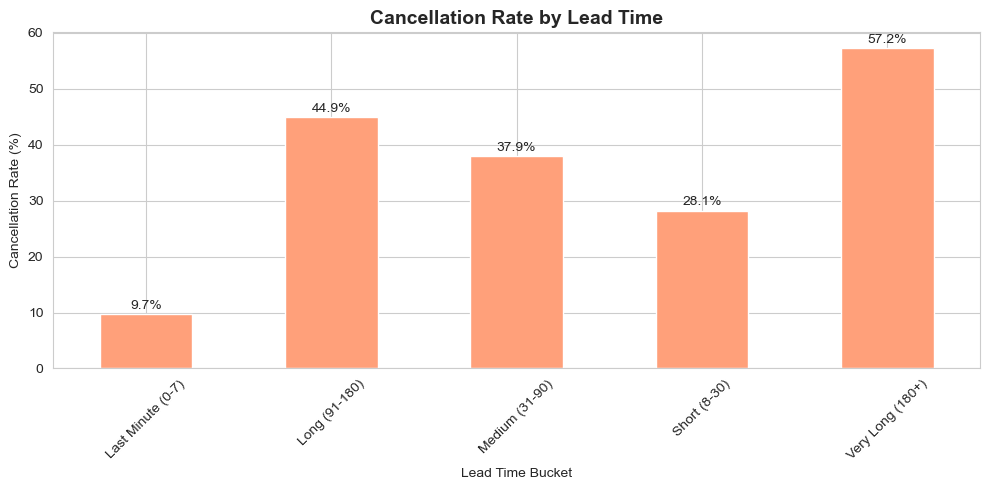


3. DEPOSIT TYPE ANALYSIS
deposit_type
No Deposit    28.711251
Non Refund    99.362446
Refundable    22.222222
Name: is_canceled, dtype: float64


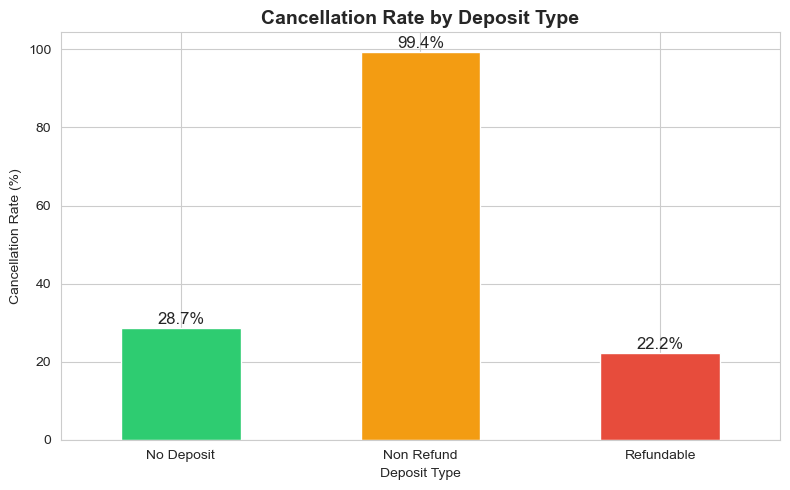


4. SEASONAL TRENDS


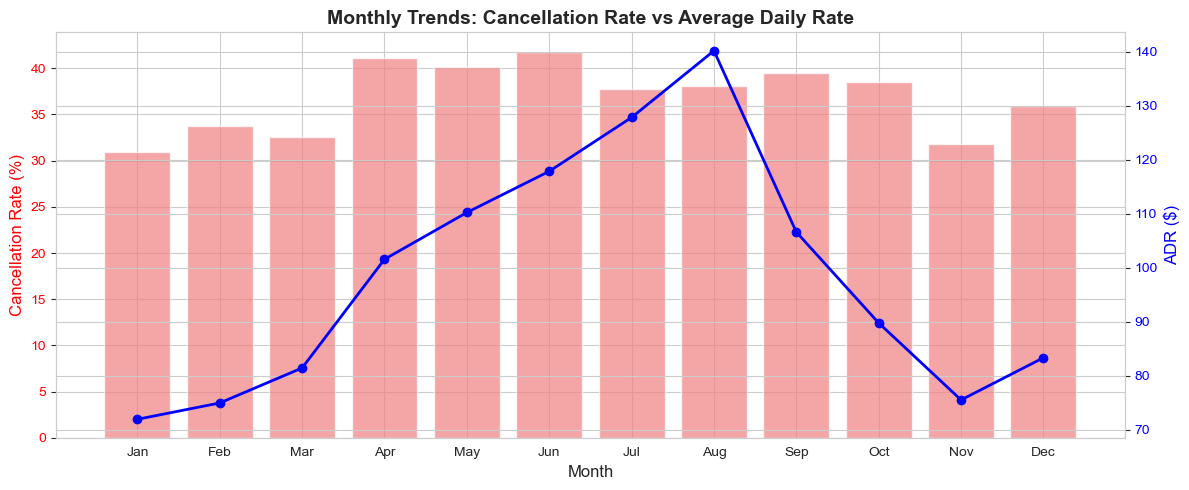


5. CORRELATION ANALYSIS


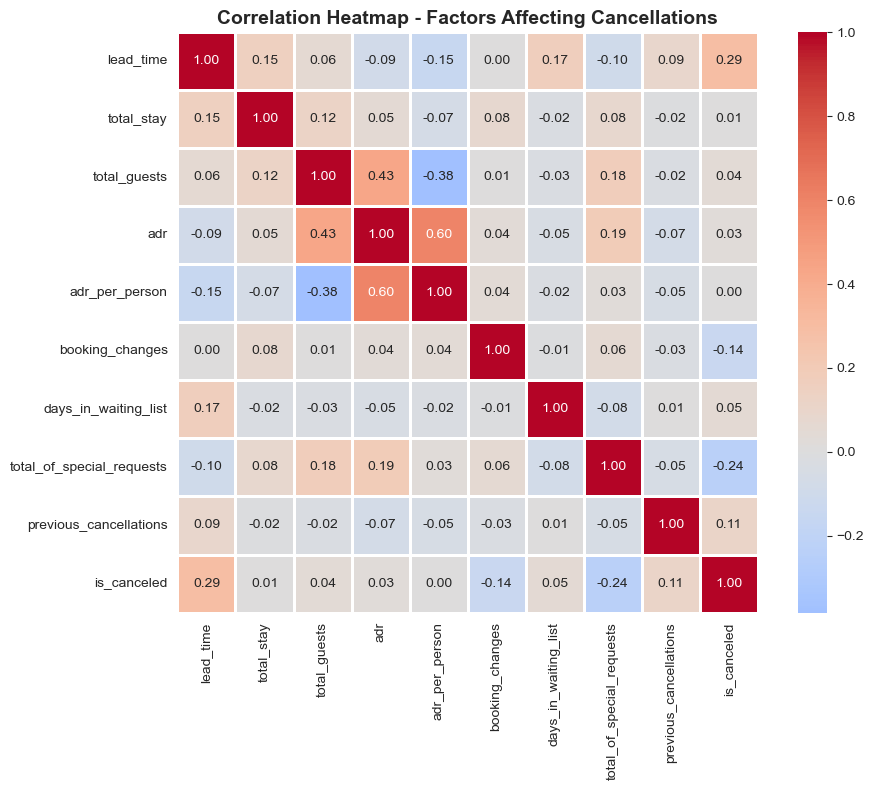


📊 Top factors correlated with cancellation:
is_canceled                  1.000000
lead_time                    0.290542
previous_cancellations       0.110671
days_in_waiting_list         0.054126
total_guests                 0.040282
adr                          0.032279
total_stay                   0.011088
adr_per_person               0.003464
booking_changes             -0.144828
total_of_special_requests   -0.237306
Name: is_canceled, dtype: float64

6. PRICING ANALYSIS


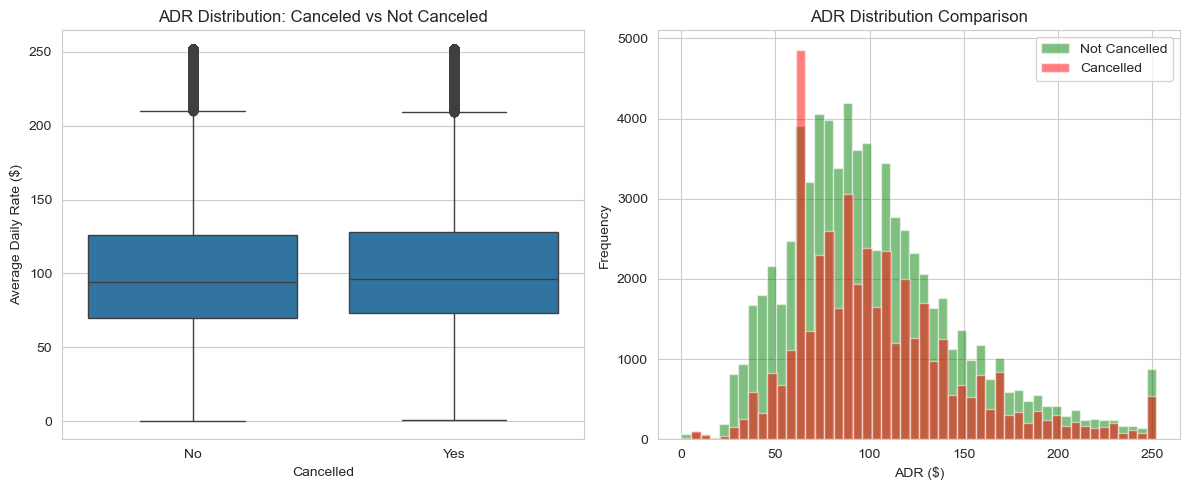

💰 Average ADR - Not Canceled: $102.02
💰 Average ADR - Canceled: $105.05
💰 Difference: $3.03

7. SPECIAL REQUESTS ANALYSIS
total_of_special_requests
0    48.313567
1    22.241574
2    22.322338
3    18.144499
4    10.802469
5     5.000000
Name: is_canceled, dtype: float64


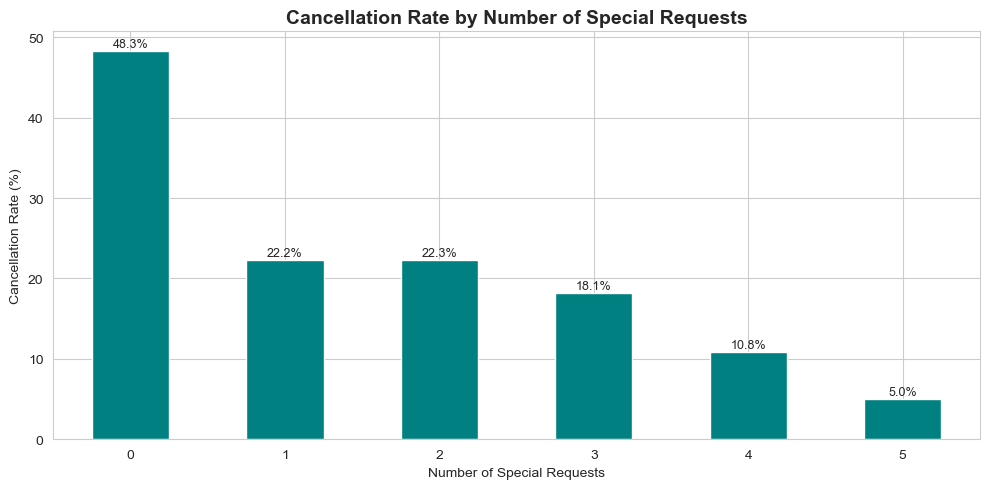


8. CUSTOMER TYPE ANALYSIS
customer_type
Contract           31.120434
Group               7.720588
Transient          41.238388
Transient-Party    25.742775
Name: is_canceled, dtype: float64


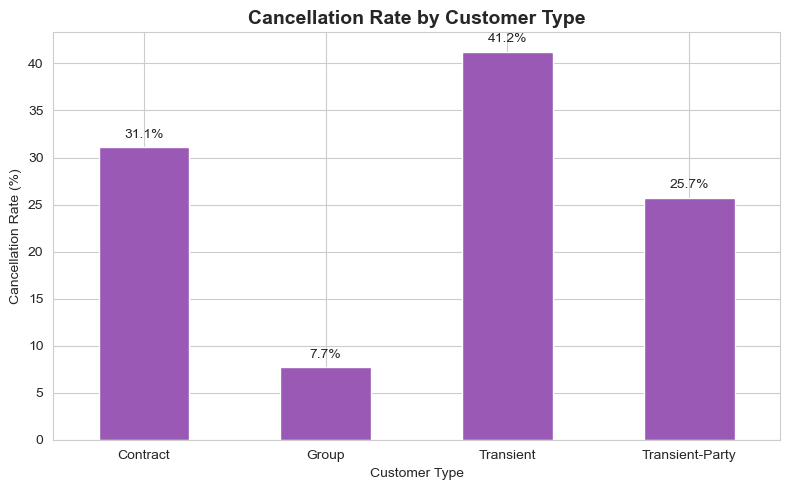


9. BOOKING CURVE


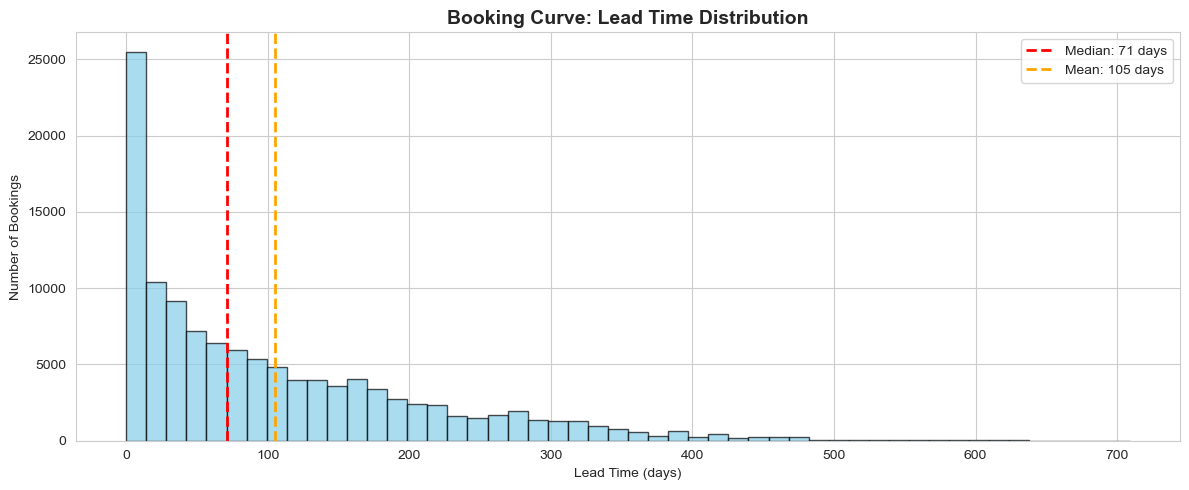

📊 Lead Time Statistics:
   Mean: 105.1 days
   Median: 71.0 days
   Min: 0.0 days
   Max: 709.0 days

WEEK 2 - KEY BUSINESS INSIGHTS

📌 CANCELLATION INSIGHTS:
   • Overall cancellation rate: 37.5%
   • City Hotel hotels have higher cancellation rate (42.2%)
   • Customers who book Very Long (180+) are most likely to cancel (57.2%)

📌 DEPOSIT & PAYMENT:
   • Best for retention: Refundable deposit (22.2% cancellation)
   • Riskiest: Non Refund deposit (99.4% cancellation)

📌 PRICING INSIGHTS:
   • Canceled bookings have $105.05 average ADR
   • Non-canceled have $102.02 average ADR

📌 SPECIAL REQUESTS:
   • Customers with 0 requests cancel 48.3% of the time
   • Customers with 5+ requests cancel only 5.0% of the time

📌 RECOMMENDATIONS:
   1. Require deposits for high-risk lead times (>180 days)
   2. Offer incentives for special requests to increase commitment
   3. Adjust pricing dynamically based on seasonal demand
   4. Target retention campaigns for Resort Hotel customers


🎉🎉🎉🎉🎉🎉🎉🎉

In [1]:
# ============================================
# WEEK 2: Exploratory Data Analysis (EDA)
# Travel & Hospitality - Customer Retention Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 50)
print("WEEK 2: EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# ============================================
# Load cleaned data from Week 1
# ============================================

df = pd.read_csv('C:/Users/achar/OneDrive/Documents/GitHub/data-analytics-projects/Travel-Hospitality-Project/Data/hotel_bookings.csv')

print("\n Data loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📊 Columns: {len(df.columns)}")

# Verify Week 1 features exist
features = ['total_stay', 'lead_time_bucket', 'total_guests', 'has_weekend', 'is_summer', 'adr_per_person', 'arrival_month']
print("\n✅ Verifying Week 1 features:")
for f in features:
    if f in df.columns:
        print(f"   ✓ {f}")
    else:
        print(f"   ✗ {f} missing")

# ============================================
# 1. Overall Cancellation Rate
# ============================================

print("\n" + "=" * 50)
print("1. CANCELLATION RATE ANALYSIS")
print("=" * 50)

cancel_rate = df['is_canceled'].mean() * 100
print(f"📊 Overall Cancellation Rate: {cancel_rate:.2f}%")

# By hotel type
hotel_cancel = df.groupby('hotel')['is_canceled'].mean() * 100
print("\n📊 Cancellation Rate by Hotel Type:")
print(hotel_cancel)

# Visualize
plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4']
hotel_cancel.plot(kind='bar', color=colors)
plt.title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Hotel Type')
plt.ylim(0, 50)
plt.xticks(rotation=0)
for i, v in enumerate(hotel_cancel):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# 2. Lead Time vs Cancellation
# ============================================

print("\n" + "=" * 50)
print("2. LEAD TIME ANALYSIS")
print("=" * 50)

lead_time_cancel = df.groupby('lead_time_bucket')['is_canceled'].mean() * 100
print(lead_time_cancel)

plt.figure(figsize=(10, 5))
lead_time_cancel.plot(kind='bar', color='#FFA07A')
plt.title('Cancellation Rate by Lead Time', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time Bucket')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
for i, v in enumerate(lead_time_cancel):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

# ============================================
# 3. Deposit Type Impact
# ============================================

print("\n" + "=" * 50)
print("3. DEPOSIT TYPE ANALYSIS")
print("=" * 50)

deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean() * 100
print(deposit_cancel)

plt.figure(figsize=(8, 5))
colors = ['#2ECC71', '#F39C12', '#E74C3C']
deposit_cancel.plot(kind='bar', color=colors)
plt.title('Cancellation Rate by Deposit Type', fontsize=14, fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(deposit_cancel):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# 4. Seasonal Trends (Monthly)
# ============================================

print("\n" + "=" * 50)
print("4. SEASONAL TRENDS")
print("=" * 50)

monthly_stats = df.groupby('arrival_month').agg({
    'is_canceled': 'mean',
    'adr': 'mean'
}).reset_index()
monthly_stats['is_canceled'] = monthly_stats['is_canceled'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar plot for cancellation rate
bars = ax1.bar(monthly_stats['arrival_month'], monthly_stats['is_canceled'], 
               color='lightcoral', alpha=0.7, label='Cancellation Rate')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Cancellation Rate (%)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')

# Line plot for ADR
ax2 = ax1.twinx()
line = ax2.plot(monthly_stats['arrival_month'], monthly_stats['adr'], 
                color='blue', marker='o', linewidth=2, label='Average Daily Rate')
ax2.set_ylabel('ADR ($)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Monthly Trends: Cancellation Rate vs Average Daily Rate', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

# ============================================
# 5. Correlation Heatmap
# ============================================

print("\n" + "=" * 50)
print("5. CORRELATION ANALYSIS")
print("=" * 50)

numerical_cols = ['lead_time', 'total_stay', 'total_guests', 'adr', 'adr_per_person', 
                  'booking_changes', 'days_in_waiting_list', 'total_of_special_requests',
                  'previous_cancellations', 'is_canceled']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Heatmap - Factors Affecting Cancellations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top factors correlated with cancellation
corr_with_cancel = corr_matrix['is_canceled'].sort_values(ascending=False)
print("\n📊 Top factors correlated with cancellation:")
print(corr_with_cancel)

# ============================================
# 6. ADR Distribution by Cancellation Status
# ============================================

print("\n" + "=" * 50)
print("6. PRICING ANALYSIS")
print("=" * 50)

plt.figure(figsize=(12, 5))

# Box plot
plt.subplot(1, 2, 1)
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.title('ADR Distribution: Canceled vs Not Canceled', fontsize=12)
plt.xlabel('Cancelled')
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel('Average Daily Rate ($)')

# Histogram
plt.subplot(1, 2, 2)
for status, color in zip([0, 1], ['green', 'red']):
    subset = df[df['is_canceled'] == status]
    plt.hist(subset['adr'], bins=50, alpha=0.5, color=color, 
             label='Cancelled' if status == 1 else 'Not Cancelled')
plt.xlabel('ADR ($)')
plt.ylabel('Frequency')
plt.title('ADR Distribution Comparison')
plt.legend()

plt.tight_layout()
plt.show()

print(f"💰 Average ADR - Not Canceled: ${df[df['is_canceled']==0]['adr'].mean():.2f}")
print(f"💰 Average ADR - Canceled: ${df[df['is_canceled']==1]['adr'].mean():.2f}")
print(f"💰 Difference: ${abs(df[df['is_canceled']==0]['adr'].mean() - df[df['is_canceled']==1]['adr'].mean()):.2f}")

# ============================================
# 7. Special Requests Impact
# ============================================

print("\n" + "=" * 50)
print("7. SPECIAL REQUESTS ANALYSIS")
print("=" * 50)

special_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean() * 100
print(special_cancel)

plt.figure(figsize=(10, 5))
special_cancel.plot(kind='bar', color='teal')
plt.title('Cancellation Rate by Number of Special Requests', fontsize=14, fontweight='bold')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(special_cancel):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 8. Customer Type Analysis
# ============================================

print("\n" + "=" * 50)
print("8. CUSTOMER TYPE ANALYSIS")
print("=" * 50)

customer_cancel = df.groupby('customer_type')['is_canceled'].mean() * 100
print(customer_cancel)

plt.figure(figsize=(8, 5))
customer_cancel.plot(kind='bar', color='#9B59B6')
plt.title('Cancellation Rate by Customer Type', fontsize=14, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(customer_cancel):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

# ============================================
# 9. Booking Curve (Lead Time Distribution)
# ============================================

print("\n" + "=" * 50)
print("9. BOOKING CURVE")
print("=" * 50)

plt.figure(figsize=(12, 5))
plt.hist(df['lead_time'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Booking Curve: Lead Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')
plt.axvline(df['lead_time'].median(), color='red', linestyle='--', linewidth=2, 
            label=f'Median: {df["lead_time"].median():.0f} days')
plt.axvline(df['lead_time'].mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Mean: {df["lead_time"].mean():.0f} days')
plt.legend()
plt.tight_layout()
plt.show()

print(f"📊 Lead Time Statistics:")
print(f"   Mean: {df['lead_time'].mean():.1f} days")
print(f"   Median: {df['lead_time'].median():.1f} days")
print(f"   Min: {df['lead_time'].min():.1f} days")
print(f"   Max: {df['lead_time'].max():.1f} days")

# ============================================
# 10. WEEK 2 SUMMARY - KEY INSIGHTS
# ============================================

print("\n" + "=" * 60)
print("WEEK 2 - KEY BUSINESS INSIGHTS")
print("=" * 60)

print(f"""
📌 CANCELLATION INSIGHTS:
   • Overall cancellation rate: {cancel_rate:.1f}%
   • {hotel_cancel.idxmax()} hotels have higher cancellation rate ({hotel_cancel.max():.1f}%)
   • Customers who book {lead_time_cancel.idxmax()} are most likely to cancel ({lead_time_cancel.max():.1f}%)

📌 DEPOSIT & PAYMENT:
   • Best for retention: {deposit_cancel.idxmin()} deposit ({deposit_cancel.min():.1f}% cancellation)
   • Riskiest: {deposit_cancel.idxmax()} deposit ({deposit_cancel.max():.1f}% cancellation)

📌 PRICING INSIGHTS:
   • Canceled bookings have ${df[df['is_canceled']==1]['adr'].mean():.2f} average ADR
   • Non-canceled have ${df[df['is_canceled']==0]['adr'].mean():.2f} average ADR

📌 SPECIAL REQUESTS:
   • Customers with 0 requests cancel {special_cancel[0]:.1f}% of the time
   • Customers with 5+ requests cancel only {special_cancel[5]:.1f}% of the time

📌 RECOMMENDATIONS:
   1. Require deposits for high-risk lead times (>180 days)
   2. Offer incentives for special requests to increase commitment
   3. Adjust pricing dynamically based on seasonal demand
   4. Target retention campaigns for Resort Hotel customers
""")

print("\n" + "🎉" * 20)
print("WEEK 2 COMPLETED SUCCESSFULLY!")
print("🎉" * 20)